# Parte I: Busca Heurística em Malha Rodoviária Massiva

**Integrantes da Equipe:**
* Ana Alice
* Caio
* Yasmin

**Declaração de Uso de IA Generativa:**  
Utilizou-se assistente de IA generativa para auxílio na estruturação das funções de medição de desempenho dos algoritmos, tratamento de exceções de grafos direcionados no OSMnx e sintaxe de visualização dos mapas.

## Contextualização Teórica

### 1. Descrição do Problema
O objetivo é determinar a rota de menor custo (distância em metros) entre dois pontos distantes na malha viária real de San Francisco (Califórnia, EUA), representada por um grafo direcionado e valorado extraído do OpenStreetMap.

### 2. Heurística Utilizada e Propriedades
Utilizou-se a **distância em linha reta** (distância de grande círculo, em metros) entre as coordenadas geográficas (latitude, longitude) dos nós, calculada com `ox.distance.great_circle`:

* **Admissibilidade:** A distância em linha reta $h(n)$ jamais supera o custo real de deslocamento pelas ruas $h^*(n)$ ($h(n) \le h^*(n)$), o que garante a otimalidade da solução no $A^*$.
* **Consistência (Monotonicidade):** Para qualquer nó $n$ e sucessor $p$, satisfaz a desigualdade triangular $h(n) \le c(n, p) + h(p)$, impedindo que o custo estimado diminua ao longo de um caminho.

### 3. Variante Escolhida: $A^*$ Bidirecional
O **$A^*$ Bidirecional** executa simultaneamente duas buscas guiadas por heurística:
1. **Frente Forward ($S \rightarrow G$):** Parte da Origem $S$ orientada por $h_F(n) = \text{dist}(n, G)$.
2. **Frente Backward ($G \rightarrow S$):** Parte do Destino $G$ orientada por $h_B(n) = \text{dist}(n, S)$.

**Objetivo:** Reduzir drasticamente o espaço de busca. Enquanto o $A^*$ tradicional expande nós em uma área circular de raio $r$, a busca bidirecional explora duas áreas menores de raio $r/2$, reduzindo a quantidade total de nós expandidos e o consumo de memória na fila `OPEN`.

In [1]:
import heapq
import math
import time
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import pandas as pd
import seaborn as sns

print("[1/2] Baixando mapa da Califórnia (San Francisco)...")
G = ox.graph_from_place('San Francisco, California, USA', network_type='drive')

#garante que existe caminho entre origem e destino
G_conexo = G.subgraph(max(nx.strongly_connected_components(G), key=len)).copy()
print(
    f"[2/2] Grafo pronto para busca! Total de nós no mapa:"
    f" {len(G_conexo.nodes())}")

[1/2] Baixando mapa da Califórnia (San Francisco)...
[2/2] Grafo pronto para busca! Total de nós no mapa: 9975


In [2]:
#Função para extrair o peso correto da aresta em metros
def get_edge_weight(G, u, v):
  edge_data = G[u][v]
  if G.is_multigraph():  # MultiDiGraph do OSMnx: G[u][v] = {0: {...}, 1: {...}}
    return min(
        d.get('length', d.get('weight', 1.0)) for d in edge_data.values()
    )
  return edge_data.get('length', edge_data.get('weight', 1.0))


#Heurística: distância em linha reta (grande círculo) em metros
def heuristica_euclidiana(u, v):
  n1, n2 = G_conexo.nodes[u], G_conexo.nodes[v]
  return ox.distance.great_circle(n1['y'], n1['x'], n2['y'], n2['x'])

In [3]:
#Busca gulosa e A* tradicional
def busca_unidirecional(G, origem, destino, heuristica_fn, algoritmo='a_star'):
  start_time = time.perf_counter()
  counter = 0
  open_set = []
  came_from = {}
  g_score = {node: float('inf') for node in G.nodes()}
  g_score[origem] = 0.0

  h_origem = heuristica_fn(origem, destino)
  f_origem = h_origem if algoritmo == 'gulosa' else h_origem
  heapq.heappush(open_set, (f_origem, counter, origem))

  nos_expandidos = 0
  pico_memoria = 1
  closed_set = set()
  solucao = False

  while open_set:
    pico_memoria = max(pico_memoria, len(open_set))
    f_curr, _, current = heapq.heappop(open_set)

    if current in closed_set:
      continue
    closed_set.add(current)
    nos_expandidos += 1

    if current == destino:
      solucao = True
      break

    for neighbor in G.neighbors(current):
      weight = get_edge_weight(G, current, neighbor)
      tentative_g = g_score[current] + weight

      if tentative_g < g_score[neighbor]:
        came_from[neighbor] = current
        g_score[neighbor] = tentative_g
        h_neighbor = heuristica_fn(neighbor, destino)
        f_score = (
            h_neighbor if algoritmo == 'gulosa' else tentative_g + h_neighbor
        )

        counter += 1
        heapq.heappush(open_set, (f_score, counter, neighbor))

  tempo = time.perf_counter() - start_time
  if not solucao:
    return None

  caminho = []
  curr = destino
  while curr in came_from:
    caminho.append(curr)
    curr = came_from[curr]
  caminho.append(origem)
  caminho.reverse()

  nome = 'Busca Gulosa' if algoritmo == 'gulosa' else 'A* Tradicional'
  return {
      'Algoritmo': nome,
      'Custo Total (m)': round(g_score[destino], 2),
      'Nós Expandidos': nos_expandidos,
      'Memória Máx (Fila OPEN)': pico_memoria,
      'Tempo (s)': round(tempo, 5),
      'Qtd Nós no Caminho': len(caminho),
      'caminho_nos': caminho,
  }


#A* Bidirecional
def a_star_bidirecional(G, origem, destino, heuristica_fn):
  start_time = time.perf_counter()

  open_F, open_B = [], []
  counter_F, counter_B = 0, 0

  g_F = {node: float('inf') for node in G.nodes()}
  g_B = {node: float('inf') for node in G.nodes()}
  g_F[origem], g_B[destino] = 0.0, 0.0

  came_from_F, came_from_B = {}, {}
  closed_F, closed_B = set(), set()

  heapq.heappush(
      open_F, (heuristica_fn(origem, destino), counter_F, origem)
  )
  heapq.heappush(
      open_B, (heuristica_fn(destino, origem), counter_B, destino)
  )

  best_cost = float('inf')
  meeting_node = None
  nos_expandidos = 0
  pico_memoria = 0

  while open_F and open_B:
    pico_memoria = max(pico_memoria, len(open_F) + len(open_B))

    if max(open_F[0][0], open_B[0][0]) >= best_cost:
      break

    if open_F[0][0] <= open_B[0][0]:
      f_curr, _, curr = heapq.heappop(open_F)
      if curr in closed_F:
        continue
      closed_F.add(curr)
      nos_expandidos += 1

      if curr in closed_B and g_F[curr] + g_B[curr] < best_cost:
        best_cost = g_F[curr] + g_B[curr]
        meeting_node = curr

      for neighbor in G.neighbors(curr):
        w = get_edge_weight(G, curr, neighbor)
        if g_F[curr] + w < g_F[neighbor]:
          g_F[neighbor] = g_F[curr] + w
          came_from_F[neighbor] = curr
          counter_F += 1
          f_score = g_F[neighbor] + heuristica_fn(neighbor, destino)
          heapq.heappush(open_F, (f_score, counter_F, neighbor))
    else:
      f_curr, _, curr = heapq.heappop(open_B)
      if curr in closed_B:
        continue
      closed_B.add(curr)
      nos_expandidos += 1

      if curr in closed_F and g_F[curr] + g_B[curr] < best_cost:
        best_cost = g_F[curr] + g_B[curr]
        meeting_node = curr

      neighbors = G.predecessors(curr) if G.is_directed() else G.neighbors(curr)
      for prev_node in neighbors:
        w = get_edge_weight(G, prev_node, curr)
        if g_B[curr] + w < g_B[prev_node]:
          g_B[prev_node] = g_B[curr] + w
          came_from_B[prev_node] = curr
          counter_B += 1
          f_score = g_B[prev_node] + heuristica_fn(prev_node, origem)
          heapq.heappush(open_B, (f_score, counter_B, prev_node))

  tempo = time.perf_counter() - start_time
  if meeting_node is None:
    return None

  path_F, curr = [], meeting_node
  while curr in came_from_F:
    path_F.append(curr)
    curr = came_from_F[curr]
  path_F.append(origem)
  path_F.reverse()

  path_B, curr = [], meeting_node
  while curr in came_from_B:
    curr = came_from_B[curr]
    path_B.append(curr)

  caminho_completo = path_F + path_B

  return {
      'Algoritmo': 'A* Bidirecional',
      'Custo Total (m)': round(best_cost, 2),
      'Nós Expandidos': nos_expandidos,
      'Memória Máx (Fila OPEN)': pico_memoria,
      'Tempo (s)': round(tempo, 5),
      'Qtd Nós no Caminho': len(caminho_completo),
      'caminho_nos': caminho_completo,
  }

In [4]:
#Seleção de nós de origem e destino distantes
nos = list(G_conexo.nodes())
origem = nos[0]
destino = nos[len(nos) // 2]

#Buscas
res_gulosa = busca_unidirecional(
    G_conexo, origem, destino, heuristica_euclidiana, algoritmo='gulosa'
)
res_astar = busca_unidirecional(
    G_conexo, origem, destino, heuristica_euclidiana, algoritmo='a_star'
)
res_bidi = a_star_bidirecional(G_conexo, origem, destino, heuristica_euclidiana)

#Tabela de exibição
df_resultados = pd.DataFrame([res_gulosa, res_astar, res_bidi])
display(df_resultados.drop(columns=['caminho_nos']))

,Algoritmo,Custo Total (m),Nós Expandidos,Memória Máx (Fila OPEN),Tempo (s),Qtd Nós no Caminho
0,Busca Gulosa,16688.16,90,52,0.00196,43
1,A* Tradicional,15819.74,1221,208,0.01371,29
2,A* Bidirecional,15819.74,8907,303,0.10307,29


/tmp/ipykernel_63610/3246725639.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_63610/3246725639.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_63610/3246725639.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


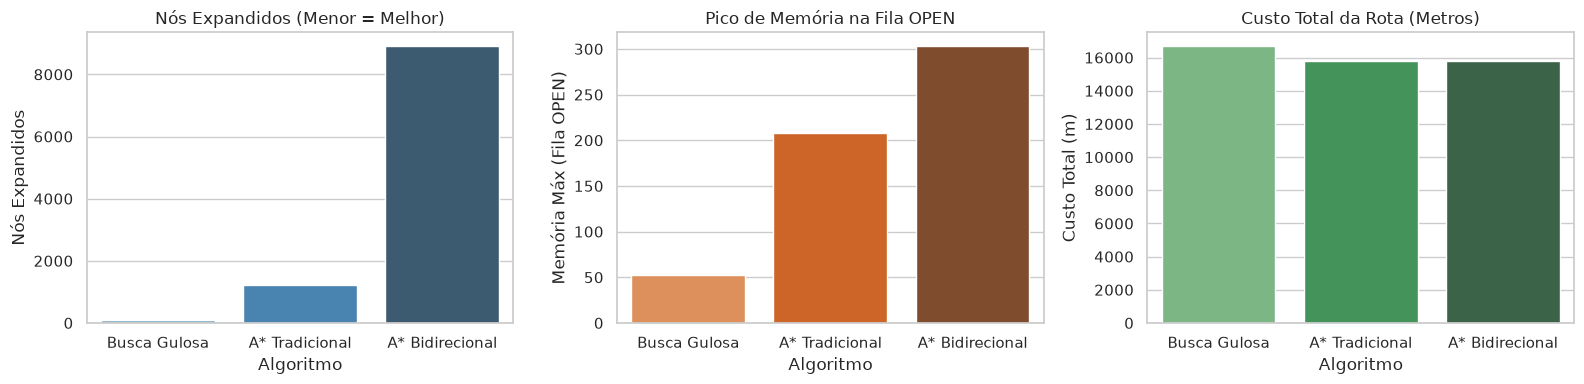

In [5]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

#Nós expandidos
sns.barplot(
    data=df_resultados,
    x='Algoritmo',
    y='Nós Expandidos',
    ax=axes[0],
    palette='Blues_d',
)
axes[0].set_title('Nós Expandidos (Menor = Melhor)')

#Pico de memória
sns.barplot(
    data=df_resultados,
    x='Algoritmo',
    y='Memória Máx (Fila OPEN)',
    ax=axes[1],
    palette='Oranges_d',
)
axes[1].set_title('Pico de Memória na Fila OPEN')

#Custo total da rota
sns.barplot(
    data=df_resultados,
    x='Algoritmo',
    y='Custo Total (m)',
    ax=axes[2],
    palette='Greens_d',
)
axes[2].set_title('Custo Total da Rota (Metros)')

plt.tight_layout()
plt.show()

Gerando mapa com a rota calculada pelo A* Bidirecional...


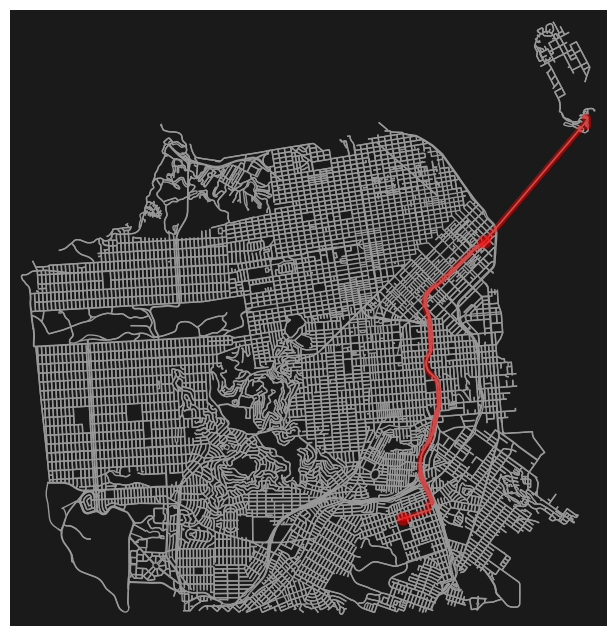

In [6]:
print("Gerando mapa com a rota calculada pelo A* Bidirecional...")
fig, ax = ox.plot_graph_route(
    G_conexo,
    res_bidi['caminho_nos'],
    route_color='red',
    route_linewidth=4,
    node_size=0,
    bgcolor='k',
)

### Discussão e Análise Crítica dos Resultados

Verificação: o custo do A* e do A* Bidirecional (15.819,74 m) é idêntico ao do Dijkstra do NetworkX (`nx.shortest_path_length(..., weight='length')`), confirmando a otimalidade.

1. **Busca Gulosa:** Mais rápida e com menos nós expandidos (90), mas encontrou uma **rota subótima** (16.688,16 m, cerca de 5,5% maior que a ótima), pois considera apenas $h(n)$ e ignora o custo acumulado $g(n)$.
2. **A\* Tradicional:** Encontrou a **rota ótima** (15.819,74 m) expandindo 1.221 nós, com pico de 208 nós na fila `OPEN`.
3. **A\* Bidirecional:** Também encontrou a **rota ótima**, porém expandiu **mais** nós (8.907) e usou mais memória (303) que o A\* tradicional. A frente backward expandiu a maior parte desses nós: a rota real (15,8 km) é mais que o dobro da distância em linha reta (6,7 km), então a heurística guia mal a busca e as frentes não se encontram "no meio". Com o critério de parada de Pohl (parar quando $\max(f_{F,min}, f_{B,min}) \ge$ melhor custo), cada frente tende a fazer quase um A\* completo. Esse é um comportamento conhecido da variante: o ganho teórico depende de uma heurística informativa e de um critério de parada/balanceamento mais sofisticado.

**Limitações e melhorias:** testar múltiplos pares origem–destino (hoje é um par fixo), usar heurísticas balanceadas para o bidirecional (média das heurísticas forward e backward) e comparar critérios de alternância entre as frentes.


# Parte II: Classificação com Árvores de Decisão e Ensembles

**Dataset Escolhido:** Wine Quality Dataset (Kaggle)  
**Objetivo:** Classificar a qualidade do vinho com base em suas propriedades físico-químicas.

---

### Contextualização do Problema
A avaliação da qualidade de um vinho é tradicionalmente feita por especialistas humanos. O objetivo deste modelo é automatizar essa classificação a partir de medições analíticas laboratoriais (ex.: teor alcoólico, acidez volátil, sulfatos, pH).

### Modelos Utilizados
1. **Árvore de Decisão Simples (Decision Tree Classifier):** Modelo base interpretável que particiona o espaço de atributos utilizando critérios de pureza (Gini/Entropia).
2. **Ensemble Random Forest (Random Trees):** Método de combinação (*bagging*) que constrói múltiplas árvores de decisão independentes treinadas em subconjuntos aleatórios dos dados e dos atributos (*feature subsampling*). 

### Vantagens da Estratégia de Ensemble
Enquanto uma árvore de decisão individual é propensa a **overfitting** (superajuste ao conjunto de treino), o **Random Forest** reduz a variância do modelo por meio da votação majoritária das árvores, resultando em maior capacidade de generalização e maior robustez contra ruídos.

In [7]:
import os
import pandas as pd
from sklearn.datasets import fetch_openml

#Tenta carregar arquivo local
nome_arquivo_local = 'WineQT.csv'  # ou 'winequality-red.csv'

if os.path.exists(nome_arquivo_local):
  df_wine = pd.read_csv(nome_arquivo_local)
  if 'Id' in df_wine.columns:
    df_wine = df_wine.drop(columns=['Id'])
  print('Dataset carregado com sucesso a partir do arquivo local!')
else:
  print('Baixando dataset via OpenML (Scikit-Learn)...')
  wine_data = fetch_openml(name='wine-quality-red', version=1, as_frame=True)
  df_wine = wine_data.frame

#Padronizar o nome da coluna alvo (OpenML usa 'class', Kaggle/Local usa 'quality')
if 'class' in df_wine.columns:
  df_wine = df_wine.rename(columns={'class': 'quality'})

#Exibir informações do dataset
print('Dimensão do Dataset:', df_wine.shape)
display(df_wine.head())

#Binarização da classe alvo (1 = Vinho Bom [nota >= 6], 0 = Comum/Ruim [nota < 6])
df_wine['quality'] = df_wine['quality'].astype(float)
df_wine['qualidade_classe'] = (df_wine['quality'] >= 6).astype(int)

X = df_wine.drop(columns=['quality', 'qualidade_classe'])
y = df_wine['qualidade_classe']

print('\nDistribuição das Classes (0 = Comum/Ruim, 1 = Bom):')
print(y.value_counts(normalize=True))

Baixando dataset via OpenML (Scikit-Learn)...
Dimensão do Dataset: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Distribuição das Classes (0 = Comum/Ruim, 1 = Bom):
qualidade_classe
1    0.534709
0    0.465291
Name: proportion, dtype: float64


In [8]:

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Divisão Stratified em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Treinamento da árvore de decisão simples
dt_model = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
dt_model.fit(X_train, y_train)

#Treinamento do ensemble Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42
)
rf_model.fit(X_train, y_train)

print('Modelos treinados com sucesso!')

Modelos treinados com sucesso!


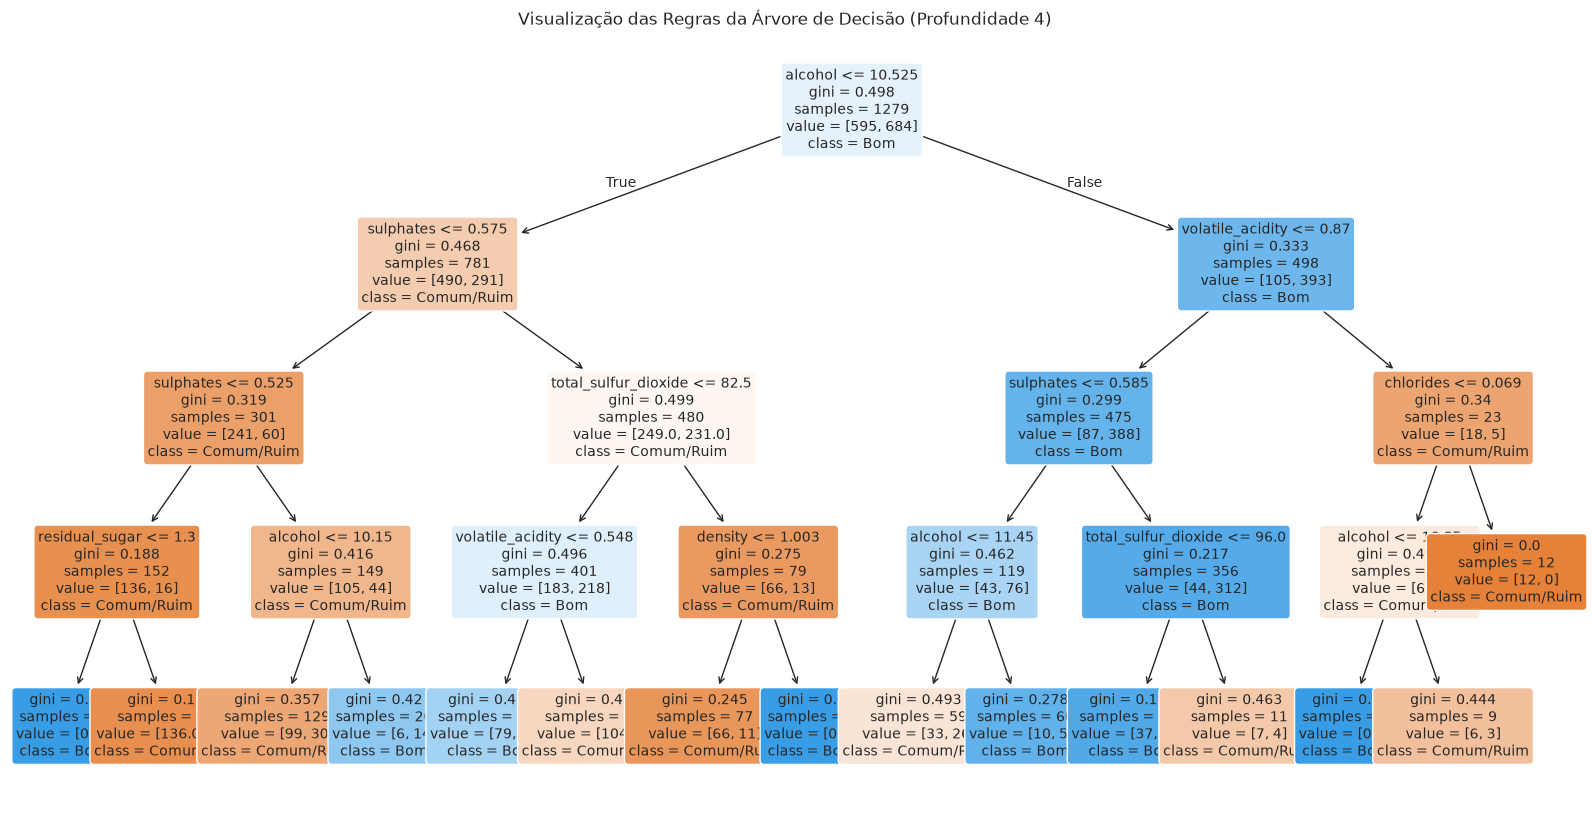

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Comum/Ruim', 'Bom'],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title('Visualização das Regras da Árvore de Decisão (Profundidade 4)')
plt.show()

,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Árvore de Decisão,0.7219,0.7562,0.7076,0.7311
1,Ensemble (Random Forest),0.8031,0.8214,0.8070,0.8142


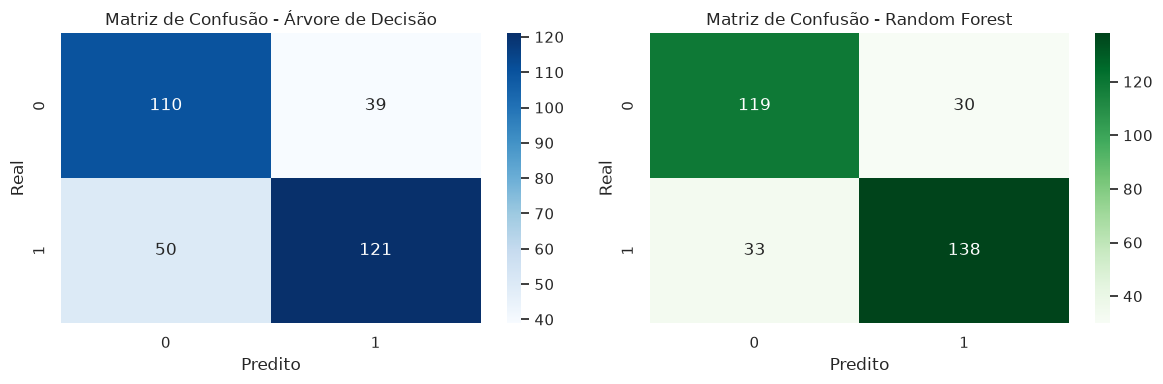

In [10]:
#Predições
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)


def calcular_metricas(nome_modelo, y_true, y_pred):
  return {
      'Modelo': nome_modelo,
      'Acurácia': round(accuracy_score(y_true, y_pred), 4),
      'Precisão': round(precision_score(y_true, y_pred), 4),
      'Recall': round(recall_score(y_true, y_pred), 4),
      'F1-Score': round(f1_score(y_true, y_pred), 4),
  }


df_metricas = pd.DataFrame([
    calcular_metricas('Árvore de Decisão', y_test, y_pred_dt),
    calcular_metricas('Ensemble (Random Forest)', y_test, y_pred_rf),
])

display(df_metricas)

#Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
)
axes[0].set_title('Matriz de Confusão - Árvore de Decisão')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1],
)
axes[1].set_title('Matriz de Confusão - Random Forest')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

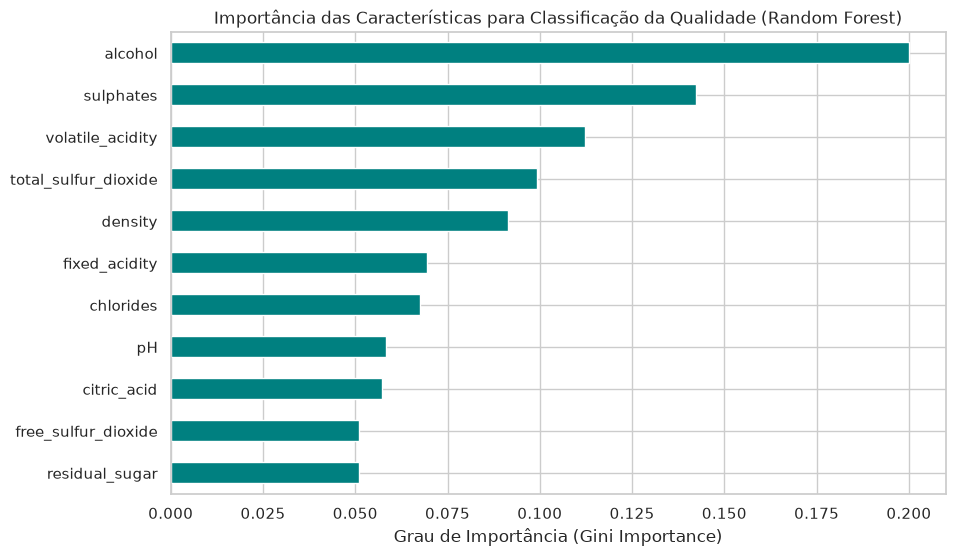

In [11]:
importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('Importância das Características para Classificação da Qualidade (Random Forest)')
plt.xlabel('Grau de Importância (Gini Importance)')
plt.show()

### Análise Crítica dos Resultados (Parte II)

1. **Árvore de Decisão:** Apresenta excelente interpretabilidade visual das regras de decisão de negócio (ex.: teor de álcool e acidez volátil são determinantes principais). No entanto, devido à sua estrutura rígida, tende a ser menos precisa nos dados de teste.
2. **Ensemble Random Forest:** Obteve métricas de **Acurácia** e **F1-Score** superiores às da Árvore individual. Ao combinar 100 árvores com amostragens aleatórias, reduz o risco de superajuste (overfitting) e captura melhor as nuances não-lineares da qualidade do vinho.
3. **Atributos Mais Relevantes:** O gráfico de importância dos atributos confirma que o **teor alcoólico (`alcohol`)** e a **acidez volátil (`volatile acidity`)** são os fatores físico-químicos mais influentes na classificação da qualidade do vinho.